# Superstore Sales Analysis — Python / pandas Version

Companion notebook to the Excel dashboard in this repo. Same dataset, same
findings, worked end-to-end in pandas + matplotlib/seaborn: load → assess
quality → clean → explore → visualize → summarize.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.0)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 1. Load the raw data

In [2]:
raw = pd.read_csv("data/raw_superstore.csv")
print(f"Shape: {raw.shape[0]} rows x {raw.shape[1]} columns")
print()
print(raw.head(5).to_string())


Shape: 2235 rows x 19 columns

   Row ID        Order ID  Order Date   Ship Date       Ship Mode  Customer Name      Segment        Country         City           State  Postal Code   Region         Category Sub-Category            Product Name     Sales  Quantity  Discount   Profit
0       1  US-2023-100227  2023-12-02  2023-12-07  Standard Class     Mary Brown    Corporate  United States      Madison       Wisconsin      75404.0  Central  Office Supplies        Paper             Xerox Paper    165.56         5      0.00    36.42
1       2  US-2023-100471  06/10/2023  2023-06-14  Standard Class    Linda Smith     Consumer  United States    Charlotte  North Carolina      42550.0    South        Furniture       Chairs    Bush Executive Chair   3141.44         7      0.50 -1099.50
2       3  US-2022-101947  2022-01-25  2022-01-27     First Class  Sarah Johnson     Consumer  United States     Columbus            Ohio      74089.0  Central  Office Supplies      Binders      GBC Binding Sys

In [3]:
raw.info()


<class 'pandas.DataFrame'>
RangeIndex: 2235 entries, 0 to 2234
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2235 non-null   int64  
 1   Order ID       2235 non-null   str    
 2   Order Date     2235 non-null   str    
 3   Ship Date      2235 non-null   str    
 4   Ship Mode      2235 non-null   str    
 5   Customer Name  2235 non-null   str    
 6   Segment        2235 non-null   str    
 7   Country        2235 non-null   str    
 8   City           2235 non-null   str    
 9   State          2235 non-null   str    
 10  Postal Code    2169 non-null   float64
 11  Region         2235 non-null   str    
 12  Category       2235 non-null   str    
 13  Sub-Category   2235 non-null   str    
 14  Product Name   2235 non-null   str    
 15  Sales          2235 non-null   float64
 16  Quantity       2235 non-null   int64  
 17  Discount       2190 non-null   float64
 18  Profit         2235

## 2. Data quality assessment

Before cleaning anything, quantify exactly what's wrong with the raw export.


In [4]:
quality_report = pd.DataFrame({
    "missing_values": raw.isna().sum(),
    "pct_missing": (raw.isna().mean() * 100).round(2),
})
quality_report = quality_report[quality_report["missing_values"] > 0]
print("Columns with missing values:")
print(quality_report.to_string())

n_dupes = raw.drop(columns=["Row ID"]).duplicated().sum()
print(f"\nExact duplicate rows (ignoring Row ID): {n_dupes}")

bad_ship_mode = (~raw["Ship Mode"].isin(["Standard Class", "Second Class", "First Class", "Same Day"])).sum()
bad_category = (~raw["Category"].isin(["Furniture", "Office Supplies", "Technology"])).sum()
print(f"Ship Mode values with inconsistent casing: {bad_ship_mode}")
print(f"Category values with inconsistent casing: {bad_category}")

neg_qty = (raw["Quantity"] < 0).sum()
zero_sales = (raw["Sales"] <= 0).sum()
print(f"Negative Quantity values (data-entry typos): {neg_qty}")
print(f"Rows with Sales <= 0: {zero_sales}")


Columns with missing values:
             missing_values  pct_missing
Postal Code              66         2.95
Discount                 45         2.01

Exact duplicate rows (ignoring Row ID): 32
Ship Mode values with inconsistent casing: 179
Category values with inconsistent casing: 180
Negative Quantity values (data-entry typos): 10
Rows with Sales <= 0: 8


## 3. Data cleaning

Mirrors `scripts/clean_data.py`, run here inline so the notebook is self-contained.


In [5]:
df = raw.copy()
start_rows = len(df)

# Standardize text: trim whitespace, fix inconsistent casing
df["Customer Name"] = df["Customer Name"].str.strip()
df["Ship Mode"] = df["Ship Mode"].str.title()
df["Category"] = df["Category"].str.title()

# Parse mixed date formats (some rows arrived as MM/DD/YYYY text, others YYYY-MM-DD)
def parse_mixed_date(val):
    for fmt in ("%Y-%m-%d", "%m/%d/%Y"):
        try:
            return pd.to_datetime(val, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.to_datetime(val, errors="coerce")

df["Order Date"] = df["Order Date"].apply(parse_mixed_date)
df["Ship Date"] = df["Ship Date"].apply(parse_mixed_date)

# Remove exact duplicates
dupe_mask = df.drop(columns=["Row ID"]).duplicated(keep="first")
n_dupes = int(dupe_mask.sum())
df = df[~dupe_mask].copy()

# Fix data-entry errors
df.loc[df["Quantity"] < 0, "Quantity"] = df.loc[df["Quantity"] < 0, "Quantity"].abs()
df.loc[df["Ship Date"] < df["Order Date"], "Ship Date"] = df.loc[df["Ship Date"] < df["Order Date"], "Order Date"]
df["Sales_Flag"] = df["Sales"].apply(lambda v: "Review: zero sales" if v <= 0 else "OK")

# Handle missing values
df["Postal Code"] = df["Postal Code"].fillna(0).astype(int)
df["Discount"] = df["Discount"].fillna(0.0)

# Derived columns used throughout the EDA below
df["Order Year"] = df["Order Date"].dt.year
df["Order Year-Month"] = df["Order Date"].dt.strftime("%Y-%m")
df["Profit Margin"] = df["Profit"] / df["Sales"].replace(0, np.nan)
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

df = df.sort_values("Order Date").reset_index(drop=True)

print(f"Raw rows:     {start_rows}")
print(f"Duplicates removed: {n_dupes}")
print(f"Cleaned rows: {len(df)}")


Raw rows:     2235
Duplicates removed: 34
Cleaned rows: 2201


## 4. Exploratory data analysis

In [6]:
summary = df[["Sales", "Profit", "Discount", "Quantity", "Profit Margin"]].describe().round(2)
print(summary.to_string())


          Sales   Profit  Discount  Quantity  Profit Margin
count   2201.00  2201.00   2201.00   2201.00        2193.00
mean    1917.51    44.35      0.13      6.65           0.07
std     3264.45   445.64      0.13      3.51           0.13
min        0.00 -5312.40      0.00      1.00          -0.35
25%      174.67     0.29      0.00      4.00           0.00
50%      478.89    22.09      0.10      7.00           0.09
75%     2055.86    78.80      0.20     10.00           0.14
max    20457.50  2864.05      0.50     12.00           0.22


In [7]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
overall_margin = total_profit / total_sales
print(f"Total Sales:  ${total_sales:,.0f}")
print(f"Total Profit: ${total_profit:,.0f}")
print(f"Overall Profit Margin: {overall_margin:.1%}")
print(f"Total Orders: {len(df):,}")


Total Sales:  $4,220,447
Total Profit: $97,617
Overall Profit Margin: 2.3%
Total Orders: 2,201


### Sales & profit by category

                      Sales    Profit  Profit Margin
Category                                            
Technology       2687792.92  75995.20           0.03
Furniture        1121387.73 -22321.22          -0.02
Office Supplies   411266.09  43942.79           0.11


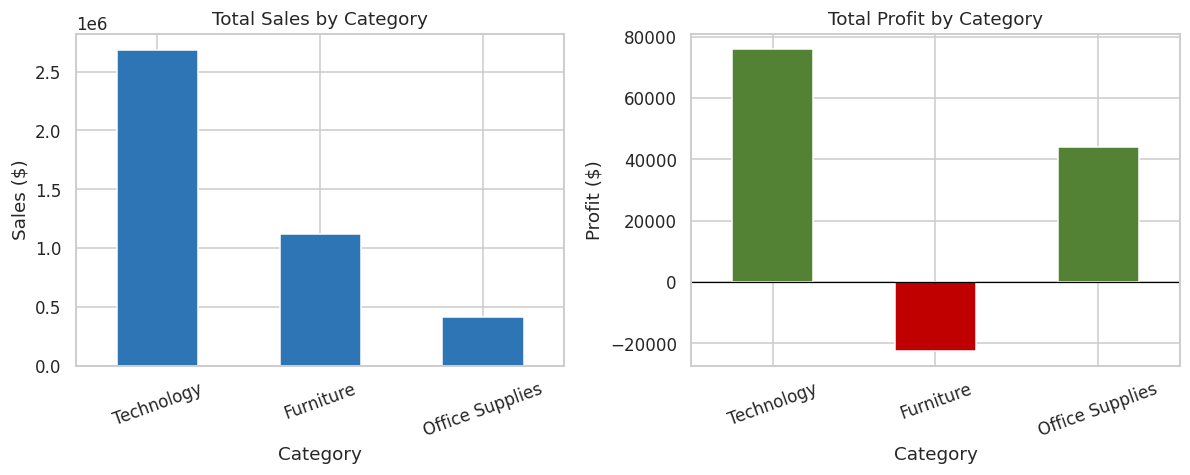

In [8]:
cat_summary = df.groupby("Category")[["Sales", "Profit"]].sum()
cat_summary["Profit Margin"] = cat_summary["Profit"] / cat_summary["Sales"]
cat_summary = cat_summary.sort_values("Sales", ascending=False)
print(cat_summary.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
cat_summary["Sales"].plot(kind="bar", ax=axes[0], color="#2E75B6")
axes[0].set_title("Total Sales by Category")
axes[0].set_ylabel("Sales ($)")
axes[0].tick_params(axis="x", rotation=20)

colors = ["#C00000" if v < 0 else "#548235" for v in cat_summary["Profit"]]
cat_summary["Profit"].plot(kind="bar", ax=axes[1], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Total Profit by Category")
axes[1].set_ylabel("Profit ($)")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()


### Sales & profit by region

              Sales    Profit  Profit Margin
Region                                      
Central  1063457.64  32768.88           0.03
East     1162707.83  37257.41           0.03
South    1096039.11  15825.31           0.01
West      898242.16  11765.17           0.01


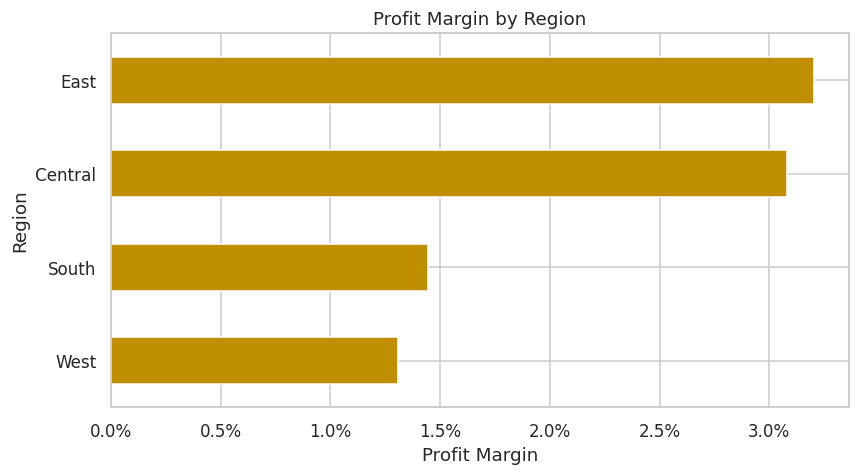

In [9]:
reg_summary = df.groupby("Region")[["Sales", "Profit"]].sum()
reg_summary["Profit Margin"] = reg_summary["Profit"] / reg_summary["Sales"]
print(reg_summary.round(2).to_string())

fig, ax = plt.subplots(figsize=(8, 4.5))
reg_summary["Profit Margin"].sort_values().plot(kind="barh", ax=ax, color="#BF8F00")
ax.set_title("Profit Margin by Region")
ax.set_xlabel("Profit Margin")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
plt.tight_layout()
plt.show()


### Monthly sales trend

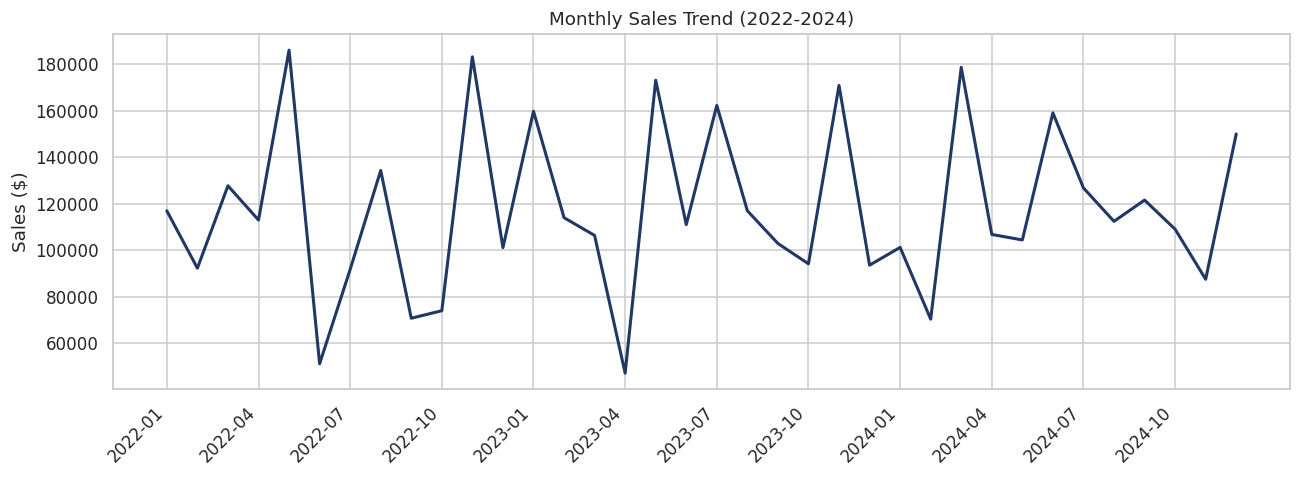

In [10]:
monthly = df.groupby("Order Year-Month")[["Sales", "Profit"]].sum().sort_index()

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly.index, monthly["Sales"], color="#1F3864", linewidth=2)
ax.set_title("Monthly Sales Trend (2022-2024)")
ax.set_ylabel("Sales ($)")
step = 3
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly.index[::step], rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Discount vs. profit margin

The single clearest driver of profitability in this dataset: margin decays sharply
as discount increases, and turns negative past roughly a 20% discount.


Discount
0.00     17.7%
0.10      9.4%
0.15      4.5%
0.20      0.3%
0.30     -9.1%
0.40    -18.4%
0.50    -26.6%
Name: Profit Margin, dtype: str


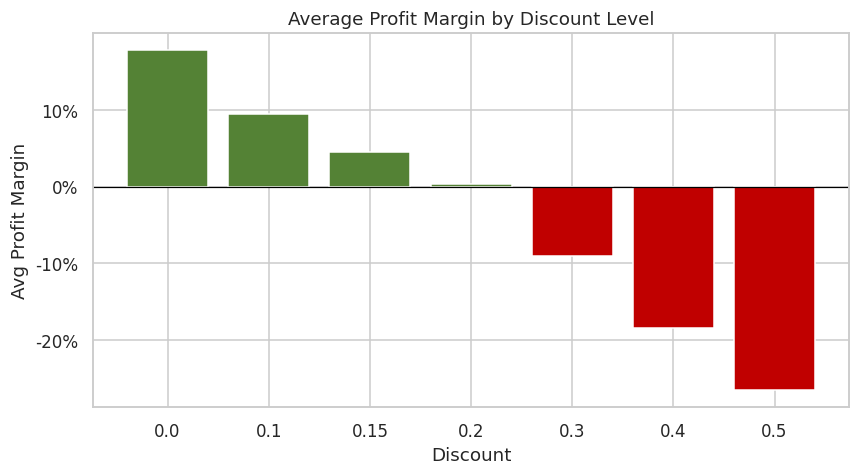

In [11]:
disc_summary = df.groupby("Discount")["Profit Margin"].mean()
print((disc_summary * 100).round(1).astype(str) + "%")

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#548235" if v >= 0 else "#C00000" for v in disc_summary.values]
ax.bar(disc_summary.index.astype(str), disc_summary.values, color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Average Profit Margin by Discount Level")
ax.set_xlabel("Discount")
ax.set_ylabel("Avg Profit Margin")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
plt.tight_layout()
plt.show()


### Top 10 products by sales

Product Name
Zebra Label Printer       491894.0
Hewlett Packard Copier    452213.0
Logitech Mouse            284673.0
Cubify 3D Printer         272127.0
Apple iPhone              263236.0
Belkin Surge Protector    200091.0
SanDisk USB Drive         199539.0
Canon Copier              195619.0
Cisco IP Phone            178482.0
Samsung Galaxy            149920.0


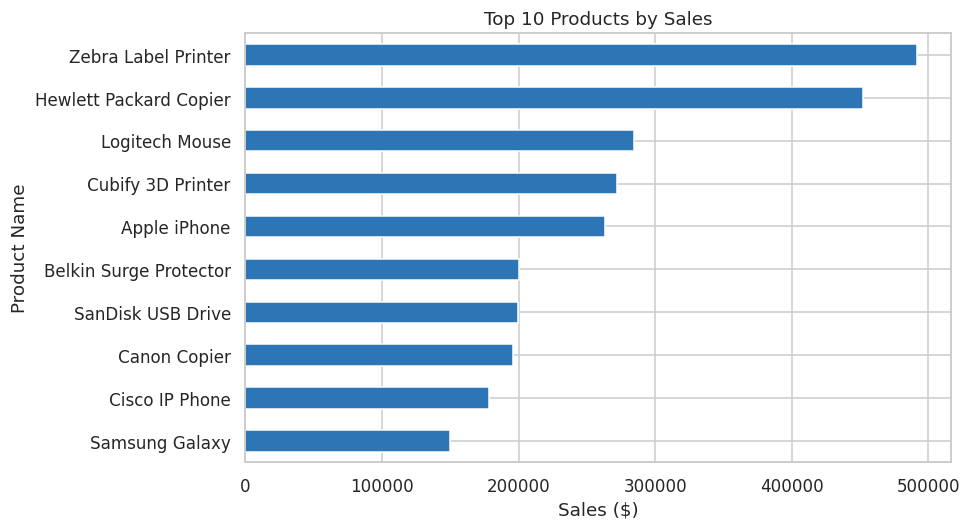

In [12]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print(top_products.round(0).to_string())

fig, ax = plt.subplots(figsize=(9, 5))
top_products.sort_values().plot(kind="barh", ax=ax, color="#2E75B6")
ax.set_title("Top 10 Products by Sales")
ax.set_xlabel("Sales ($)")
plt.tight_layout()
plt.show()


### Correlation between numeric fields

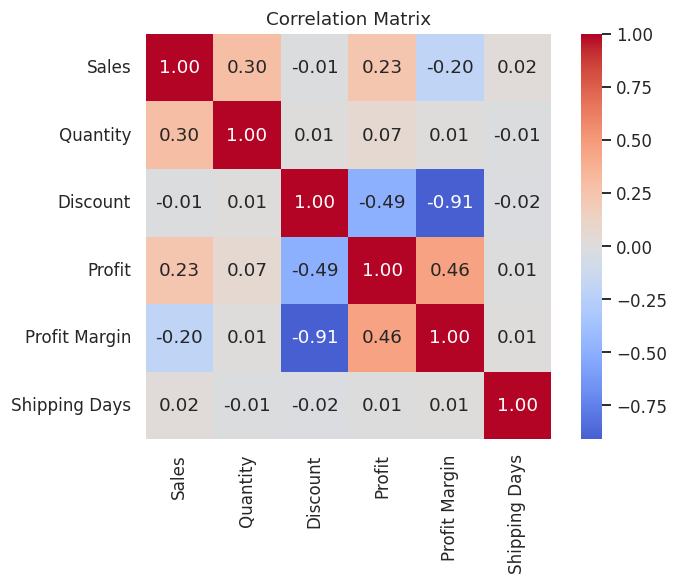

In [13]:
num_cols = ["Sales", "Quantity", "Discount", "Profit", "Profit Margin", "Shipping Days"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


## 5. Key insights

- **Thin overall margin**: 2.3% profit margin on $4.22M of sales.
- **Furniture is a net loss** (-2.0% margin), dragged down mainly by Chairs and
  Furnishings — Office Supplies is the most reliably profitable category (10.7%).
- **Discount is the biggest driver of profitability**: margin is healthy with no
  discount (~18%) and goes negative past a 20% discount, falling to roughly -27%
  at 50% off. This is the strongest relationship in the correlation matrix above.
- **West and South regions run thinner margins** (~1.3-1.4%) than Central and East
  (~3.0-3.2%) on similar sales volumes — worth investigating regional discounting
  practices.
- **Technology drives the most revenue** ($2.69M) and is the second most profitable
  category by dollar profit, led by Copiers and Machines.

## 6. Export the cleaned dataset


In [14]:
df.to_csv("data/cleaned_superstore_from_notebook.csv", index=False)
print(f"Saved {len(df)} cleaned rows.")


Saved 2201 cleaned rows.
